In [17]:
#importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [26]:
#reading us_pop_data csv as pandas dataframe
census_df = pd.read_csv("us_pop_data.csv")

#displaying dataset info and first few rows
census_df.info()
census_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    23 non-null     int64
 1   us_pop  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


,year,us_pop
0,1790,3929326
1,1800,5308483
2,1810,7239881
3,1820,9638453
4,1830,12866020


In [3]:
#creating column for number of years since 1790
census_df["year_count"] = census_df["year"] - 1790

#creating column for population in millions
census_df["us_pop_mill"] = census_df["us_pop"] / 1_000_000
census_df.head()

,year,us_pop,year_count,us_pop_mill
0,1790,3929326,0,3.929326
1,1800,5308483,10,5.308483
2,1810,7239881,20,7.239881
3,1820,9638453,30,9.638453
4,1830,12866020,40,12.866020


In [4]:
#creating Linear Regression model using sklearn
lr = LinearRegression()

#setting x and y variables
X = census_df[["year_count"]]
y = census_df["us_pop_mill"]

#fitting model, and using model to predict y-value for all points
model = lr.fit(X,y)
y_pred = model.predict(X)

#evaluating model's R-Squared Score
model.score(X, y)

0.9192437447080442

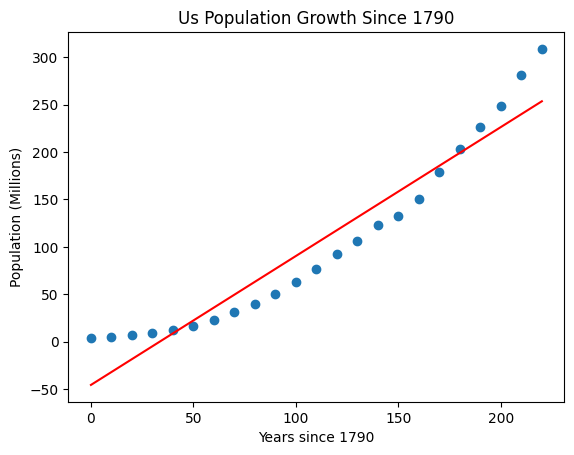

In [5]:
#creating scatter plot, and displaying Linear Regression Line
plt.scatter(census_df["year_count"], census_df["us_pop_mill"])
plt.plot(census_df["year_count"], y_pred, color = "red")
plt.title("Us Population Growth Since 1790")
plt.ylabel("Population (Millions)")
plt.xlabel("Years since 1790")
plt.show()

In [6]:
#creating column with square of years since 1790
census_df["year_count_squared"] = census_df["year_count"]**2
census_df.head()

,year,us_pop,year_count,us_pop_mill,year_count_squared
0,1790,3929326,0,3.929326,0
1,1800,5308483,10,5.308483,100
2,1810,7239881,20,7.239881,400
3,1820,9638453,30,9.638453,900
4,1830,12866020,40,12.866020,1600


In [7]:
#fitting linear regression model using square of year count as independent variable
square_model = lr.fit(census_df[["year_count_squared"]], y)
squared_y_preds = square_model.predict(census_df[["year_count_squared"]])
model.score(census_df[["year_count_squared"]], y)

0.9984915694986646

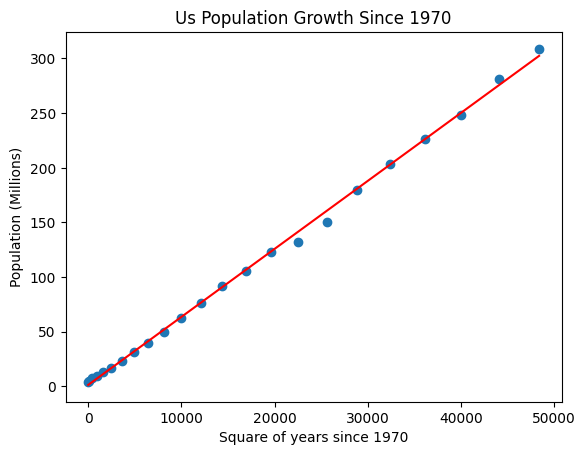

In [8]:
#displaying scatter plot and regression line of squared model
plt.scatter(census_df["year_count_squared"], y)
plt.plot(census_df["year_count_squared"], squared_y_preds, color = "red")

plt.xlabel("Square of years since 1970")
plt.ylabel("Population (Millions)")
plt.title("Us Population Growth Since 1970")
plt.show()

The second model (which is a quadrratic model) fits the data much better than linear regression. This is apparent in the R2 scores. While both are strong, the second model is nearly 1 indicating very good fit.

In [10]:
#reading customer spending csv as pandas data frame
customer_df = pd.read_csv("customer_spending.csv")

#displaying dataset info and first few rows
customer_df.info()
customer_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ann_spending  440 non-null    int64
dtypes: int64(1)
memory usage: 3.6 KB


,ann_spending
0,34112
1,33266
2,36610
3,27381
4,46100


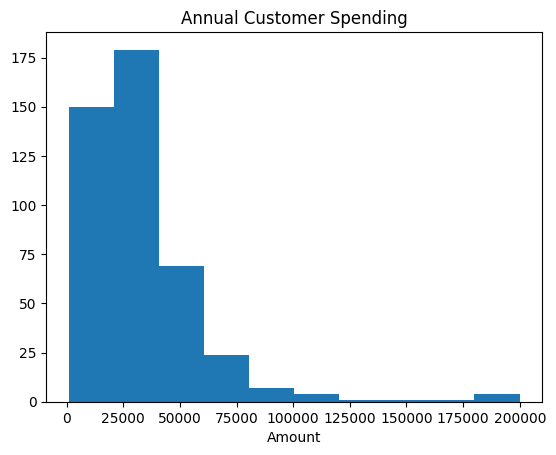

In [27]:
#creating histogram of customer spending
plt.hist(customer_df["ann_spending"])
plt.title("Annual Customer Spending")
plt.xlabel("Amount")
ax= plt.gca()
plt.show()

In [22]:
#creating column with (natural) log of customer spending
customer_df["log_ann_spending"] = np.log(customer_df["ann_spending"])
customer_df.head()

,ann_spending,log_ann_spending
0,34112,10.437405
1,33266,10.412291
2,36610,10.508077
3,27381,10.217605
4,46100,10.738568


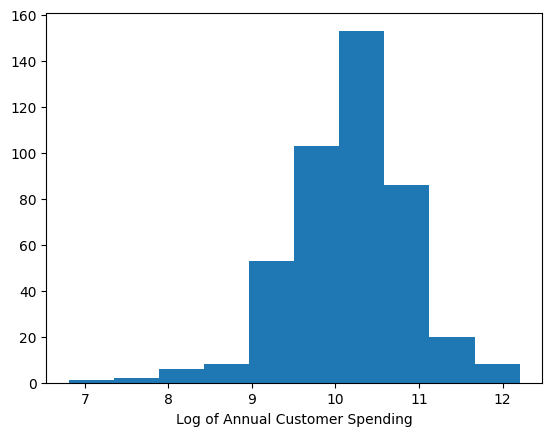

In [28]:
#creating histogram of log of customer spending
plt.hist(customer_df["log_ann_spending"])
plt.xlabel("Log of Annual Customer Spending")
plt.show()


We can see that while the orginal dataset does not follow a normal (bell-shaped) distribution, the log-transformed dataset more or less does. Whil log values add more complexity, this is one reason analysts may choose to use log transformations. Normal distributions allow many opportunities for statistical analysis and calculations, so using a log transformation can be very useful.